c:\Users\Highlightning\Documents\Ciencia de Datos\Proyectos\Churn Predictor and LTV\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:22:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "eval_metrics", "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 RESULTADOS DEL MODELO EN EL CONJUNTO DE PRUEBA 
Random Forest -> Recall: 94.59% | ROC-AUC: 0.9514
XGBoost       -> Recall: 93.51% | ROC-AUC: 0.9498


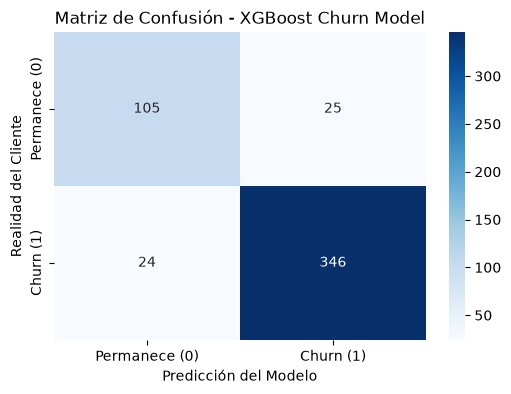

In [1]:
from sklearn.model_selection    import train_test_split
from sklearn.ensemble           import RandomForestClassifier
from xgboost                    import XGBClassifier
from sklearn.metrics            import classification_report, roc_auc_score, confusion_matrix, recall_score

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = r"C:\Users\Highlightning\Documents\Ciencia de Datos\Proyectos\Churn Predictor and LTV\data\processed\churn_feature_data.csv"
df = pd.read_csv(path)

X = df.drop(columns=["CustomerID", "Churn", "FutureLTV_12M"])
y = df["Churn"]

# Codificación One-Hot para variables categóricas (ContractType, PaymentMethod)
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Entrenamiento de Modelos
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, oob_score=True, n_jobs=-1).fit(X_train, y_train)

xgb_model = XGBClassifier(n_estimator=100, learning_rate=0.05, random_state=42, eval_metrics="logloss", n_jobs=-1).fit(X_train, y_train)

# Predicciones
y_hat_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:,1]

y_hat_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:,1]


# Resultados y Comparación de Métricas
print("="*50)
print(" RESULTADOS DEL MODELO EN EL CONJUNTO DE PRUEBA ")
print("="*50)
print(f"Random Forest -> Recall: {recall_score(y_test, y_hat_rf):.2%} | ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"XGBoost       -> Recall: {recall_score(y_test, y_hat_xgb):.2%} | ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")
print("="*50)


# Matriz de Confusión para XGBoost
cm = confusion_matrix(y_test, y_hat_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Permanece (0)', 'Churn (1)'], yticklabels=['Permanece (0)', 'Churn (1)'])
plt.title('Matriz de Confusión - XGBoost Churn Model')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad del Cliente')
plt.show()